In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
summary_df = pd.read_csv('../data/vessel_summary.csv')
cmp_df = pd.read_csv('../data/flag_change_intervals.csv')
identities_df = pd.read_csv('../data/identities.csv')

#### Visualization of the frequency of flag changes up to 2023 and thereafter

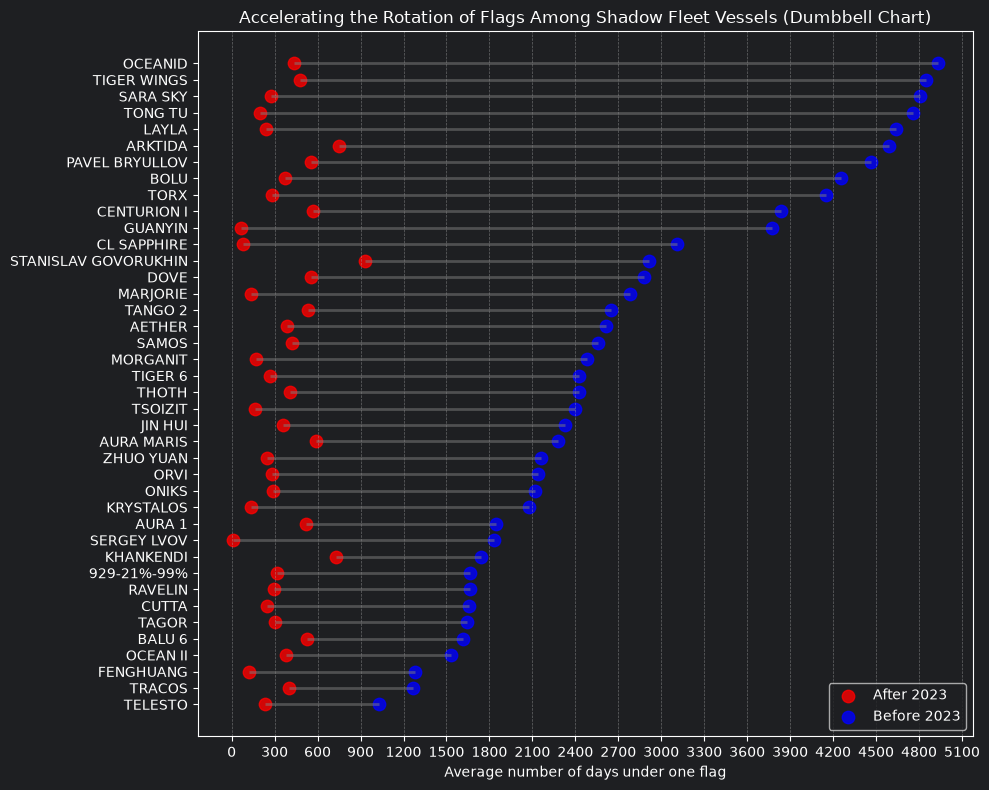

In [7]:

df = identities_df.copy()
df['transmission_from'] = pd.to_datetime(
    df['transmission_from'], format='mixed', utc=True
)
df['transmission_to'] = pd.to_datetime(
    df['transmission_to'], format='mixed', utc=True
)
# If transmission_to is null, use the current date (or data export date)
df['transmission_to'] = df['transmission_to'].fillna(pd.Timestamp.now(tz='UTC'))
df['duration_days'] = (df['transmission_to'] - df['transmission_from']).dt.days

# 2. Split into periods (before 2023 and after)
df['period'] = df['transmission_from'].apply(
    lambda x: 'before_2023' if x.year < 2023 else 'after_2023'
)

# 3. Calculate average flag ownership duration per IMO for each period
grouped = df.groupby(['imo', 'period'])['duration_days'].mean().unstack()

# Keep only vessels with data for both periods and reset index to keep IMO as a column
plot_data = grouped.dropna().reset_index()

plot_data = plot_data.merge(summary_df[['imo', 'current_name']], on='imo')

plt.figure(figsize=(10, 8))
# Sort by "before_2023" duration for visual clarity
plot_data = plot_data.sort_values('before_2023')

plt.hlines(
    y=plot_data['current_name'],
    xmin=plot_data['after_2023'],
    xmax=plot_data['before_2023'],
    color='grey',
    alpha=0.5,
    linewidth=2,
)

# Draw points
plt.scatter(
    plot_data['after_2023'],
    plot_data['current_name'],
    color='red',
    alpha=0.8,
    label='After 2023',
    s=80,
)
plt.scatter(
    plot_data['before_2023'],
    plot_data['current_name'],
    color='blue',
    alpha=0.8,
    label='Before 2023',
    s=80,
)
plt.xticks(np.arange(0, plot_data['before_2023'].max() + 300, 300))
plt.legend()
plt.xlabel('Average number of days under one flag')
plt.title(
    'Accelerating the Rotation of Flags Among Shadow Fleet Vessels (Dumbbell Chart)'
)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()